<h1 style = "color: purple; text-align: center;font-family: Poppins; font-weight: 800;">Adaptive Revenue Engine (ARE)</h1>

### [Causal + Reinforcement Learning System for Autonomous Pricing Decisions]

**An autonomous decision intelligence system that combines causal inference and reinforcement learning to dynamically optimize pricing strategies in real time, maximizing revenue while adapting to changing market conditions.**

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">1. Create a realistic synthetic data</h2>

**🎧 Product: “Wireless Bluetooth Earbuds"**

Let’s take a product — Wireless Bluetooth Earbuds in a marketplace (₹150–₹1000 pricing range) and learn optimal pricing strategies using causal inference and reinforcement learning.\
The system models how product features (battery life, noise cancellation, brand strength) and seasonality affect demand, then dynamically adjusts prices to maximize revenue. It compares intelligent pricing against a fixed baseline strategy while providing explainable insights into pricing decisions and the causal impact on demand.

In [2]:
np.random.seed(42)

In [3]:
n=5000

base_price=np.random.uniform(150, 800, n)

season=np.random.choice([0, 1, 2],n,p=[0.27, 0.4, 0.33]) #low, mid, high

noice_cancellation=np.random.choice([0, 1], n)

brand_strength= np.random.uniform(0, 1, n)

battery_life = np.random.uniform(4, 40, n)

season_multiplier=np.where(
    season == 0, 0.85,   
    np.where(season == 1, 1.0, 1.25)  
)

battery_effect = 120 * np.log1p(battery_life) / np.log1p(40)

price=(
    base_price * season_multiplier
    + battery_effect
    + 250 * (brand_strength ** 4)
    + noice_cancellation * 150
    + np.random.normal(0, 50, n)
).round(2)

In [4]:
data={
    "price":price,
    "noise_cancellation":noice_cancellation,
    "brand_strength":brand_strength,
    "battery_life":battery_life,
    "season":season}

In [5]:
df = pd.DataFrame(data)
df

,price,noise_cancellation,brand_strength,battery_life,season
0,537.04,0,0.806715,12.659759,1
1,995.80,1,0.016539,13.864889,1
2,1074.87,1,0.186808,37.146566,2
3,785.07,1,0.654905,6.762622,1
4,491.13,0,0.375759,25.944190,2
...,...,...,...,...,...
4995,1141.35,1,0.514988,29.579050,2
4996,532.94,1,0.479926,35.236800,2
4997,638.82,0,0.604710,39.123477,2
4998,965.43,1,0.479446,38.284654,1


In [6]:
season_effect=np.where(
    df["season"] == 0, np.random.uniform(-420, -120, n),
    np.where(
        df["season"] == 1, np.random.uniform(-100, 100, n),
        np.random.uniform(120, 600, n)
    )
)
df["demand"]=(
        np.random.uniform(3000, 6000, n) 
        +(-3.2 * price)
        + season_effect
        + 1000 * (brand_strength ** 4)
        + 600 * noice_cancellation
        + 950 * np.log1p(battery_life) / np.log1p(40)
        + np.random.normal(0, 150, n)
    )
df["demand"]=np.round(df["demand"])
df.head()

,price,noise_cancellation,brand_strength,battery_life,season,demand
0,537.04,0,0.806715,12.659759,1,4722.0
1,995.80,1,0.016539,13.864889,1,4214.0
2,1074.87,1,0.186808,37.146566,2,2091.0
3,785.07,1,0.654905,6.762622,1,2068.0
4,491.13,0,0.375759,25.944190,2,2809.0


In [7]:
df["revenue"]=df["price"] * df["demand"]
df

,price,noise_cancellation,brand_strength,battery_life,season,demand,revenue
0,537.04,0,0.806715,12.659759,1,4722.0,2535902.88
1,995.80,1,0.016539,13.864889,1,4214.0,4196301.20
2,1074.87,1,0.186808,37.146566,2,2091.0,2247553.17
3,785.07,1,0.654905,6.762622,1,2068.0,1623524.76
4,491.13,0,0.375759,25.944190,2,2809.0,1379584.17
...,...,...,...,...,...,...,...
4995,1141.35,1,0.514988,29.579050,2,2260.0,2579451.00
4996,532.94,1,0.479926,35.236800,2,3884.0,2069938.96
4997,638.82,0,0.604710,39.123477,2,3608.0,2304862.56
4998,965.43,1,0.479446,38.284654,1,2924.0,2822917.32


In [8]:
df.to_excel("earbuds.xlsx")

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">2. Exploratory Analysis</h2>

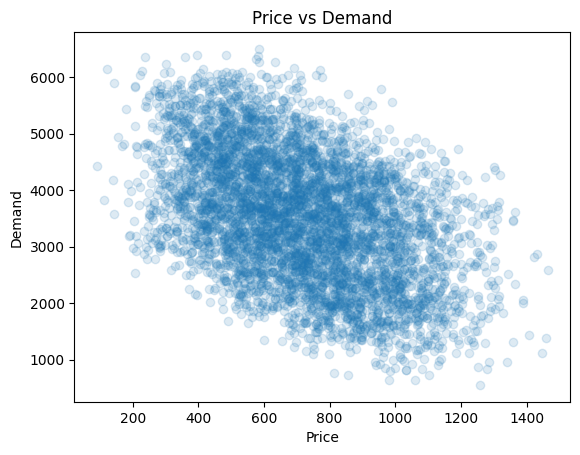

In [9]:
plt.scatter(df["price"], df["demand"], alpha=0.15)
plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Price vs Demand")
plt.show()

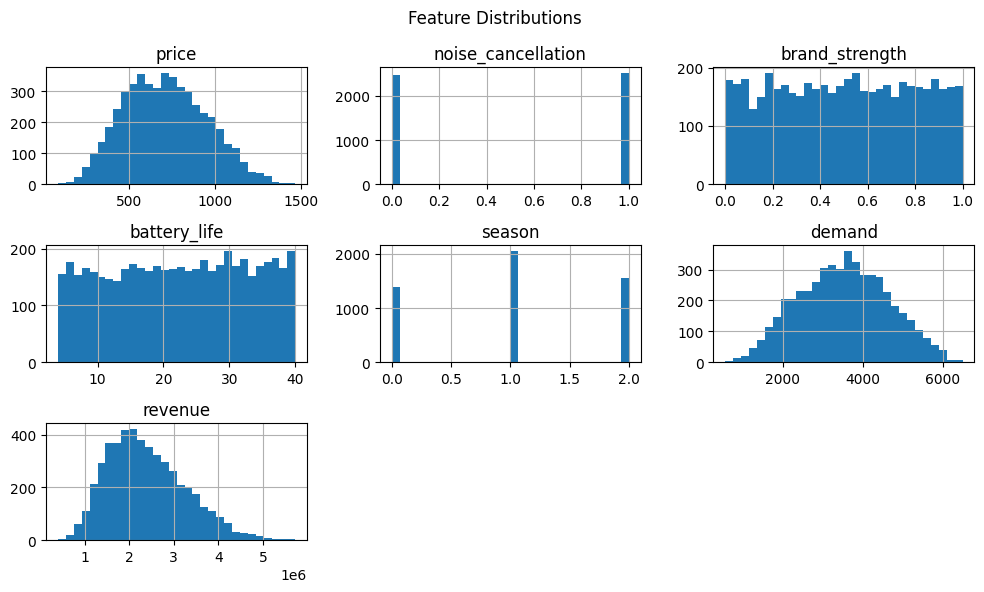

In [10]:
df.hist(figsize=(10,6), bins=30)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

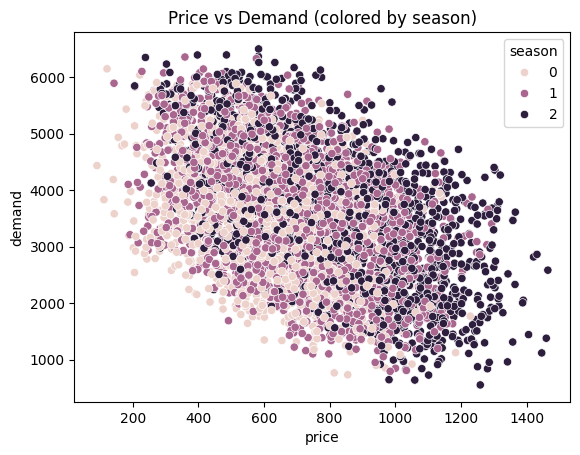

In [11]:
sns.scatterplot(data=df, x="price", y="demand", hue="season")
plt.title("Price vs Demand (colored by season)")
plt.show()

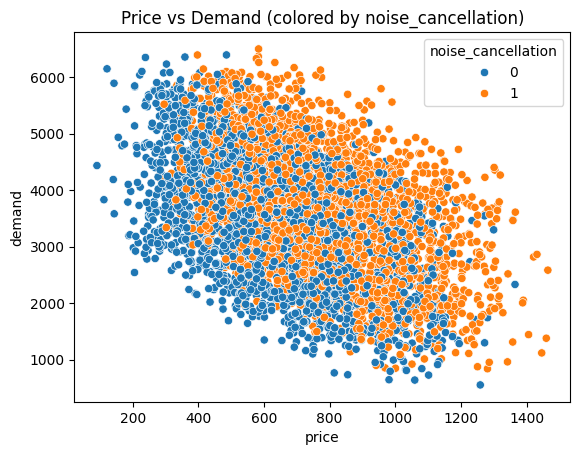

In [12]:
sns.scatterplot(data=df, x="price", y="demand", hue="noise_cancellation")
plt.title("Price vs Demand (colored by noise_cancellation)")
plt.show()

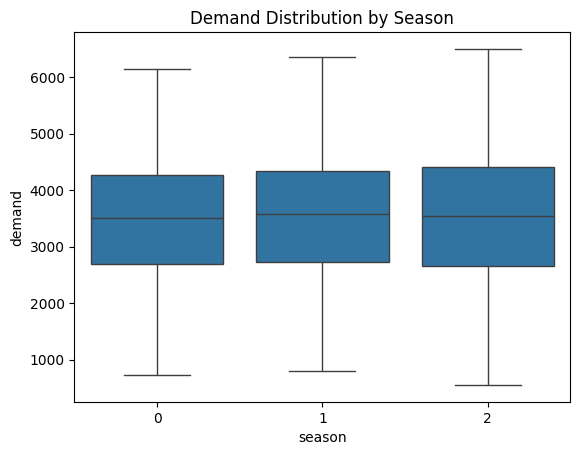

In [13]:
sns.boxplot(data=df, x="season", y="demand")
plt.title("Demand Distribution by Season")
plt.show()

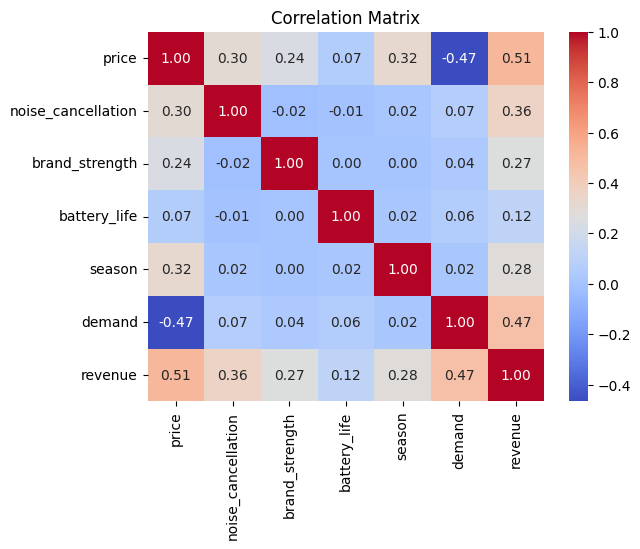

In [14]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.show()

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">3. Causal Inference</h2>

In [15]:
from dowhy import CausalModel

model=CausalModel(
    data=df,
    treatment="price",
    outcome="demand",
    common_causes=["season", "noise_cancellation", "brand_strength", "battery_life"]
)

In [16]:
identified_estimand=model.identify_effect()

In [17]:
estimate=model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression"
)

In [18]:
estimate.value

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">4. Build Environment (for RL)</h2>

In [19]:
def market_environment(price, noise_c, battery, brand, season):
    season_effect=np.where(
    season == 0, np.random.uniform(-420, -120),
    np.where(
        season == 1, np.random.uniform(-100, 100),
        np.random.uniform(120, 600)))
    demand = (
       np.random.uniform(3000, 6000) 
        +(-3.2 * price)
        + season_effect
        + 1000 * (brand ** 4)
        + 600 * noise_c
        + 950 * np.log1p(battery) / np.log1p(40)
        + np.random.normal(0, 150))
    
    demand = np.clip(demand, 0, None)
    revenue = price * demand
    
    return demand, revenue

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">5. RL Agent</h2>

In [20]:
def baseline_price():
    return df["price"].mean()  

In [21]:
def bucket_battery(battery):
    if battery < 10:
        return "low"
    elif battery < 18:
        return "medium"
    else:
        return "high"

def bucket_brand(brand):
    if brand < 0.3:
        return "weak"
    elif brand < 0.7:
        return "mid"
    else:
        return "strong"

In [22]:
class PricingAgent:
    def __init__(self, prices, epsilon=0.1):
        self.prices = prices
        self.epsilon = epsilon
        self.q = {} 
        self.count = {}
        
    def get_state(self, season, battery, brand, noise):
        return (
            season,
            bucket_battery(battery),
            bucket_brand(brand),
            noise)
    
    def choose(self, state):
       if state not in self.q:
            self.q[state] = {p: 0 for p in self.prices}
            self.count[state] = {p: 0 for p in self.prices}
       if np.random.rand() < self.epsilon:
            return np.random.choice(self.prices)
       return max(self.q[state], key=self.q[state].get)
    
    def update(self, state, price, reward):
        self.count[state][price] += 1
        n = self.count[state][price]     
        q_old = self.q[state][price]
        self.q[state][price] += (reward - q_old) / n

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">6. Train the Agent</h2>

In [23]:
prices = np.linspace(90, 1500, 25)
agent = PricingAgent(prices, epsilon=0.1)

rewards = []

for i in range(10000):
    season = np.random.choice([0,1,2])
    noise_c = np.random.choice([0,1])
    battery = np.random.uniform(4, 24)
    brand = np.random.uniform(0, 1)
    state = agent.get_state(season, battery, brand, noise_c)
    price = agent.choose(state)
    
    demand, revenue = market_environment(
        price, noise_c, battery, brand, season
    )
    
    agent.update(state, price, revenue)
    rewards.append(revenue)

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">7. Compare vs Baseline</h2>

In [24]:
baseline_rewards = []

for i in range(10000):
    season = np.random.choice([0,1,2])
    noise_c = np.random.choice([0,1])
    battery = np.random.uniform(4, 24)
    brand = np.random.uniform(0, 1)
    
    price = baseline_price()
    
    _, revenue = market_environment(price, noise_c, battery, brand, season)
    baseline_rewards.append(revenue)

print("AI Avg Revenue:", np.mean(rewards))
print("Baseline Avg Revenue:", np.mean(baseline_rewards))

AI Avg Revenue: 2273020.99001288
Baseline Avg Revenue: 2439195.1738842432


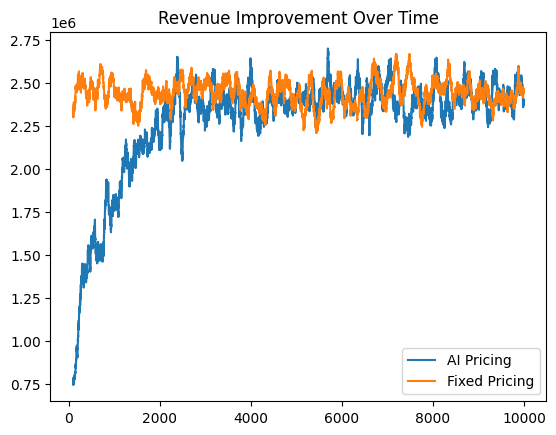

In [25]:
plt.plot(pd.Series(rewards).rolling(100).mean(), label="AI Pricing")
plt.plot(pd.Series(baseline_rewards).rolling(100).mean(), label="Fixed Pricing")
plt.legend()
plt.title("Revenue Improvement Over Time")
plt.show()

In [26]:
season = 2  
battery = 20
brand = 0.8
noise = 1

state = agent.get_state(season, battery, brand, noise)

best_price = max(agent.q[state], key=agent.q[state].get)

explanation = {
    "context": state,
    "optimal_price": best_price,
    "reason": "Learns higher price for strong demand conditions",
    "causal_effect": estimate.value
}

explanation

{'context': (2, 'high', 'strong', 1),
 'optimal_price': np.float64(971.25),
 'reason': 'Learns higher price for strong demand conditions',
 'causal_effect': np.float64(-3.189756398008285)}

The pricing model learns over time and gets close to the best possible results. It adjusts prices based on things like season, product features, and demand, instead of using one fixed price. At first, it performs similar to a strong fixed pricing strategy, but it becomes more useful when we add more realistic conditions like changing demand patterns and competition.